# LC-DA-CA1 schematic model

Author: Dinghao Luo  
Date  : 26 March 2026

This notebook distills the exploratory modelling (see `general_model_EDA.ipynb`) into one stabilised parameter set and evaluates it with `20` paired synthetic-population replicates.

Each replicate does two things:
- draws a fresh CA1 population from the same parameter distributions
- compares baseline, LC activation, and partial DA blockade on that **same** synthetic population

The three figure blocks below mirror the manuscript-style experimental comparisons:
1. baseline vs **1.5x LC activation** conditions (Fig. 2)
2. DA-targeted vs non-targeted CA1 cells (Fig. 5, top)
3. baseline vs **partial DA blockade** in CA1 (Fig. 5, bottom)

This notebook implements a schematic model of the LC-DA-CA1 PyrUp dataset from Luo et al. (2026). The goal is not to build a detailed biophysical model, but to support a mechanistic interpretation of the main results in the paper.

In this version, CA1 pyramidal neurones are driven by two smooth task-related signals and a compound dopamine trace:
- $R(t)$: a run-related drive with a faster rise and slower fall
- $W(t)$: a reward-associated suppressive drive with a faster onset and slower recovery
- $D_{\mathrm{dip}}(t)$: a pre-run DA dip
- $D_{\mathrm{rel}}(t)$: an LC-driven DA release signal whose LC peak is centred on run onset and whose DA release peaks shortly after run onset
- $D(t) = D_{\mathrm{dip}}(t) + D_{\mathrm{rel}}(t)$: the complete DA trace shown in the signal plots

For each CA1 cell $i$, the direct task input is
$$x_i(t) = b_i + w_i^R R(t) + w_i^W W(t)$$

This is converted into a non-negative firing-rate-like target using a softplus function ($\phi$ here):
$$r_i^0(t) = \phi(x_i(t))$$

Dopamine sensitivity is made smoothly firing-rate dependent with a sigmoid non-linearity:
$$m_i(t) = \sigma\left(\frac{r_i^0(t) - r_{1/2}}{k_r}\right)$$
where $r_{1/2}$ sets the turning point of the DA effect and $k_r$ controls how sharply that effect ramps up.

All CA1 cells receive a weak shared DA-sensitive component, and DA-targeted cells receive an extra increment:
$$g_i = g_{\mathrm{shared}} + I_i^{\mathrm{DA}} g_{\mathrm{extra}}$$

To match the empirical observation that DA modulation is not evident before run onset, the trace shown in the figures is separated from the effective modulatory drive used by CA1:
$$D_{\mathrm{eff}}(t) = G(t) \, D_{\mathrm{rel}}(t - \Delta_D)$$
where $G(t)$ is a smooth post-run gate and $\Delta_D$ is a downstream delay between LC-triggered DA release and its effect on CA1 excitability.

The full firing-rate target is then
$$\tilde r_i(t) = r_i^0(t) \left[1 + g_i \, m_i(t) \, D_{\mathrm{eff}}(t)\right]$$

To capture a slower cell-intrinsic return to baseline, the intrinsic timescale acts on the whole target trace,
$$\tau_i^{\mathrm{int}} \frac{dr_i}{dt} = -r_i + \tilde r_i(t)$$
implemented in code as a continuous first-order update with faster movement away from baseline and slower movement back toward baseline. In words, the direct run and reward drives remain smooth at all times, the plotted DA trace can rise before run onset, the effective modulatory influence on CA1 rises smoothly only after run onset, and the cell-specific intrinsic timescale governs how quickly the realised firing rate relaxes back toward baseline from both elevated and suppressed states.

In [28]:
# imports
import warnings
import numpy as np
import matplotlib.pyplot as plt

from copy import deepcopy
from dataclasses import dataclass
from scipy.stats import ttest_rel, wilcoxon

warnings.filterwarnings('ignore', message='Matplotlib is currently using agg')


In [29]:
@dataclass
class PARAMS:
    # simulation grid
    dt: float = 0.01
    t_pre: float = 1.00
    t_post: float = 6.00

    # bootstrap controls
    n_bootstrap: int = 20
    seed_start: int = 0
    lc_activation_fold: float = 1.50

    # population size
    n_cells: int = 1000

    # population priors
    baseline_mean: float = 1.75
    baseline_sd: float = 0.35

    wR_mean: float = 1.00
    wR_sd: float = 0.75
    wW_mean: float = 0.45
    wW_sd: float = 1.00

    # smooth DA sensitivity
    frac_da_targ: float = 0.35
    da_half_rate: float = 2.20
    da_rate_slope: float = 0.45
    da_gain_global: float = 0.75
    da_gain_targeted_extra: float = 0.35
    da_block_scale: float = 0.60
    da_mod_delay: float = 0.30
    da_gate_mid: float = 0.15
    da_gate_scale: float = 0.12

    # cell-intrinsic recovery acting on the full target trace
    intrinsic_tau_mean: float = 1.50
    intrinsic_tau_sd: float = 0.20
    intrinsic_tau_min: float = 0.35
    intrinsic_tau_max: float = 2.60
    intrinsic_tau_away_scale: float = 0.15

    # static nonlinearity / output limits
    softplus_beta: float = 2.00
    max_rate: float = 20.00

    # smooth direct-drive shapes
    run_on_mid: float = 0.18
    run_off_mid: float = 1.30
    run_rise_scale: float = 0.12
    run_fall_scale: float = 0.75
    reward_on_mid: float = 0.06
    reward_off_mid: float = 1.25
    reward_rise_scale: float = 0.11
    reward_fall_scale: float = 0.85

    # drive amplitudes
    run_amp: float = 1.10
    reward_amp: float = 0.90
    da_dip_amp: float = -0.50

    # DA dip timing
    da_dip_t: float = -0.25
    da_dip_tau: float = 0.20

    # LC drive shape
    lc_baseline: float = 1.00
    lc_amp: float = 1.50
    lc_mu: float = 0.00
    lc_sigma: float = 0.20

    # LC -> DA conversion
    lc_to_da_gain: float = 1.55
    da_tau_decay: float = 0.65

    # population analysis
    pre_window: tuple = (-1.00, -0.50)
    post_window: tuple = (0.80, 2.20)
    up_thresh: float = 1.42
    down_thresh: float = 0.75

    # numerical safeguard
    eps: float = 1e-6


class_colors = {
    'is_up': 'darkorange',
    'is_other': 'grey',
    'is_down': 'purple'
}

condition_colors = {
    'baseline': '0.35',
    'lc': class_colors['is_up'],
    'blocked': class_colors['is_down'],
    'da_targeted': class_colors['is_up'],
    'not_targeted': '0.45'
}

In [30]:
# helper functions

def window_mask(t, window):
    return (t >= window[0]) & (t < window[1])


def response_strength(rates, t, p):
    pre_mask = window_mask(t, p.pre_window)
    post_mask = window_mask(t, p.post_window)

    pre_mean = np.mean(rates[:, pre_mask], axis=1)
    post_mean = np.mean(rates[:, post_mask], axis=1)
    return post_mean / (pre_mean + p.eps)


def classify_cells(resp, p):
    is_up = resp >= p.up_thresh
    is_down = resp <= p.down_thresh
    is_other = ~(is_up | is_down)
    return {
        'is_up': is_up,
        'is_down': is_down,
        'is_other': is_other,
    }


def safe_mean_trace(rate_matrix, mask):
    if np.sum(mask) == 0:
        return np.full(rate_matrix.shape[1], np.nan)
    return np.mean(rate_matrix[mask], axis=0)


def sem(values, axis=0):
    values = np.asarray(values, dtype=float)
    count = np.sum(np.isfinite(values), axis=axis)
    spread = np.nanstd(values, axis=axis, ddof=1)
    out = spread / np.sqrt(np.maximum(count, 1))
    if np.isscalar(out):
        return np.nan if count <= 1 else float(out)
    out = np.asarray(out, dtype=float)
    out = np.where(count > 1, out, np.nan)
    return out


def describe_scalar(values):
    values = np.asarray(values, dtype=float)
    return float(np.nanmean(values)), float(sem(values, axis=0))


def baseline_subtracted_traces(traces, t, window):
    traces = np.asarray(traces, dtype=float)
    baseline = np.mean(traces[:, window_mask(t, window)], axis=1, keepdims=True)
    return traces - baseline


def format_p_value(p):
    if not np.isfinite(p):
        return 'nan'
    if p < 1e-4:
        return '<1e-4'
    return f'{p:.4f}'


def paired_test_summary(left, right):
    left = np.asarray(left, dtype=float)
    right = np.asarray(right, dtype=float)
    mask = np.isfinite(left) & np.isfinite(right)
    left = left[mask]
    right = right[mask]

    if len(left) == 0:
        return {
            'n': 0,
            'mean_left': np.nan,
            'mean_right': np.nan,
            'mean_diff': np.nan,
            'ttest_stat': np.nan,
            'ttest_p': np.nan,
            'wilcoxon_stat': np.nan,
            'wilcoxon_p': np.nan,
        }

    t_res = ttest_rel(right, left, nan_policy='omit')
    try:
        w_res = wilcoxon(right, left, zero_method='wilcox', method='approx')
        w_stat = float(w_res.statistic)
        w_p = float(w_res.pvalue)
    except ValueError:
        w_stat = np.nan
        w_p = np.nan

    return {
        'n': int(len(left)),
        'mean_left': float(np.mean(left)),
        'mean_right': float(np.mean(right)),
        'mean_diff': float(np.mean(right - left)),
        'ttest_stat': float(t_res.statistic),
        'ttest_p': float(t_res.pvalue),
        'wilcoxon_stat': w_stat,
        'wilcoxon_p': w_p,
    }


def print_paired_summary(label, left, right):
    summary = paired_test_summary(left, right)
    print(
        f'{label}: '
        f'delta = {summary["mean_diff"]:.2f}, '
        f'paired t p = {format_p_value(summary["ttest_p"])}, '
        f'Wilcoxon p = {format_p_value(summary["wilcoxon_p"])}'
    )


def plot_mean_sem(ax, t, traces, color, label, linestyle='-', alpha_fill=0.18):
    traces = np.asarray(traces, dtype=float)
    mean_trace = np.nanmean(traces, axis=0)
    sem_trace = sem(traces, axis=0)
    ax.plot(t, mean_trace, color=color, linewidth=2, linestyle=linestyle, label=label)
    ax.fill_between(
        t,
        mean_trace - sem_trace,
        mean_trace + sem_trace,
        color=color,
        alpha=alpha_fill,
        linewidth=0,
    )


def plot_paired_bar_scatter(ax, left, right, labels, colors, ylabel, title):
    left = np.asarray(left, dtype=float)
    right = np.asarray(right, dtype=float)
    mask = np.isfinite(left) & np.isfinite(right)
    left = left[mask]
    right = right[mask]

    order = np.argsort((left + right) / 2.0)
    left = left[order]
    right = right[order]

    means = np.array([np.mean(left), np.mean(right)], dtype=float)
    sems = np.array([sem(left, axis=0), sem(right, axis=0)], dtype=float)
    x = np.array([0.0, 1.0], dtype=float)

    ax.bar(x, means, width=0.56, color=colors, alpha=0.55, edgecolor='none', zorder=0)
    ax.errorbar(
        x,
        means,
        yerr=sems,
        fmt='none',
        ecolor='k',
        elinewidth=1.2,
        capsize=4,
        capthick=1.2,
        zorder=3,
    )

    x_left = np.full(len(left), x[0], dtype=float)
    x_right = np.full(len(right), x[1], dtype=float)

    for xl, xr, yl, yr in zip(x_left, x_right, left, right):
        ax.plot([xl, xr], [yl, yr], color='0.75', linewidth=0.8, zorder=1)

    ax.scatter(x_left, left, s=26, color=colors[0], edgecolor='white', linewidth=0.4, zorder=2)
    ax.scatter(x_right, right, s=26, color=colors[1], edgecolor='white', linewidth=0.4, zorder=2)

    y_all = np.concatenate([left, right, means])
    y_span = float(np.nanmax(y_all) - np.nanmin(y_all))
    if y_span <= 0:
        y_span = max(abs(float(np.nanmean(y_all))) * 0.10, 0.10)
    y_pad = 0.06 * y_span

    for xi, mean_i, sem_i in zip(x, means, sems):
        ax.text(
            xi,
            mean_i + sem_i + y_pad,
            f'{mean_i:.2f}\n+/-{sem_i:.2f} SEM',
            ha='center',
            va='bottom',
            fontsize=8,
        )

    summary = paired_test_summary(left, right)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.20)

    stats_text = (
        f'delta = {summary["mean_diff"]:.2f}\n'
        f'paired t p = {format_p_value(summary["ttest_p"])}\n'
        f'Wilcoxon p = {format_p_value(summary["wilcoxon_p"])}'
    )
    ax.text(
        0.02,
        0.98,
        stats_text,
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=9,
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='0.8', alpha=0.90),
    )
    return summary


def half_cosine(tt, t0, t1, y0, y1):
    s = np.clip((tt - t0) / (t1 - t0), 0.0, 1.0)
    return y0 + (y1 - y0) * 0.5 * (1.0 - np.cos(np.pi * s))


def sigmoid(tt, midpoint, scale):
    scale = max(scale, 1e-6)
    return 1.0 / (1.0 + np.exp(-(tt - midpoint) / scale))


def smooth_pulse(tt, onset_mid, offset_mid, rise_scale, fall_scale, amplitude, eps):
    pulse = sigmoid(tt, onset_mid, rise_scale) * (1.0 - sigmoid(tt, offset_mid, fall_scale))
    peak = np.max(pulse)
    if peak <= eps:
        return np.zeros_like(tt, dtype=float)
    return amplitude * pulse / peak


def exp_kernel(dt, tau, t_max, eps):
    tk = np.arange(0.0, t_max + dt, dt)
    k = np.exp(-tk / tau)
    k /= np.sum(k) * dt + eps
    return tk, k


def make_drives(t, p):
    R = smooth_pulse(
        t,
        p.run_on_mid,
        p.run_off_mid,
        p.run_rise_scale,
        p.run_fall_scale,
        p.run_amp,
        p.eps,
    )
    W = -smooth_pulse(
        t,
        p.reward_on_mid,
        p.reward_off_mid,
        p.reward_rise_scale,
        p.reward_fall_scale,
        p.reward_amp,
        p.eps,
    )

    D_dip = np.zeros_like(t, dtype=float)
    dip_down_mask = (t >= -p.t_pre) & (t <= p.da_dip_t)
    dip_recover_mask = t > p.da_dip_t
    D_dip[dip_down_mask] = half_cosine(t[dip_down_mask], -p.t_pre, p.da_dip_t, 0.0, p.da_dip_amp)
    D_dip[dip_recover_mask] = p.da_dip_amp * np.exp(-(t[dip_recover_mask] - p.da_dip_t) / p.da_dip_tau)

    L = p.lc_baseline + p.lc_amp * np.exp(-0.5 * ((t - p.lc_mu) / p.lc_sigma) ** 2)
    lc_excess = np.maximum(L - p.lc_baseline, 0.0)

    _, k = exp_kernel(p.dt, p.da_tau_decay, p.t_pre + p.t_post, p.eps)
    D_release = p.lc_to_da_gain * np.convolve(lc_excess, k, mode='full')[: len(t)] * p.dt
    D = D_dip + D_release

    shifted_release = np.interp(t - p.da_mod_delay, t, D_release, left=0.0, right=D_release[-1])
    da_gate = sigmoid(t, p.da_gate_mid, p.da_gate_scale)
    D_effective = shifted_release * da_gate

    return {
        'R': R,
        'W': W,
        'D': D,
        'L': L,
        'D_dip': D_dip,
        'D_release': D_release,
        'D_effective': D_effective,
        'lc_excess': lc_excess,
        'da_gate': da_gate,
    }

In [31]:
# simulation functions

def apply_intrinsic_decay_matrix(target_matrix, baseline_rate, tau_intr, tau_away_scale, dt):
    out = np.zeros_like(target_matrix)
    out[:, 0] = target_matrix[:, 0]
    tau_return = np.maximum(tau_intr, 1e-6)
    tau_away = np.maximum(tau_intr * tau_away_scale, 1e-6)

    for k in range(1, target_matrix.shape[1]):
        target = target_matrix[:, k]
        prev = out[:, k - 1]
        returning = np.abs(target - baseline_rate) < np.abs(prev - baseline_rate)
        tau_eff = np.where(returning, tau_return, tau_away)
        alpha = np.clip(dt / tau_eff, 0.0, 1.0)
        out[:, k] = prev + alpha * (target - prev)

    return np.clip(out, 0.0, None)


def make_population(p, rng):
    da_u = rng.random(p.n_cells)
    return {
        'b': rng.normal(p.baseline_mean, p.baseline_sd, p.n_cells),
        'wR': rng.normal(p.wR_mean, p.wR_sd, p.n_cells),
        'wW': rng.normal(p.wW_mean, p.wW_sd, p.n_cells),
        'tau_intr': np.clip(
            rng.normal(p.intrinsic_tau_mean, p.intrinsic_tau_sd, p.n_cells),
            p.intrinsic_tau_min,
            p.intrinsic_tau_max,
        ),
        'da_u': da_u,
        'da_targ': da_u < p.frac_da_targ,
    }


def simulate_population_condition(t, p, pop, da_scale=1.0):
    drives = make_drives(t, p)
    R = drives['R']
    W = drives['W']

    x = (
        pop['b'][:, None]
        + pop['wR'][:, None] * R[None, :]
        + pop['wW'][:, None] * W[None, :]
    )

    xb = p.softplus_beta * x
    r0 = (np.log1p(np.exp(-np.abs(xb))) + np.maximum(xb, 0.0)) / p.softplus_beta

    slope = max(p.da_rate_slope, p.eps)
    m = 1.0 / (1.0 + np.exp(-(r0 - p.da_half_rate) / slope))

    da_strength = p.da_gain_global + pop['da_targ'][:, None].astype(float) * p.da_gain_targeted_extra
    r_target = np.clip(
        r0 * (1.0 + da_strength * m * (da_scale * drives['D_effective'][None, :])),
        0.0,
        p.max_rate,
    )
    rates = apply_intrinsic_decay_matrix(
        r_target,
        r0[:, 0],
        pop['tau_intr'],
        p.intrinsic_tau_away_scale,
        p.dt,
    )

    resp = response_strength(rates, t, p)
    classes = classify_cells(resp, p)

    return {
        't': t,
        'drives': drives,
        'r0': r0,
        'm': m,
        'r_target': r_target,
        'rates': rates,
        'resp': resp,
        'classes': classes,
        'pre_mask': window_mask(t, p.pre_window),
        'post_mask': window_mask(t, p.post_window),
        'mean_traces': {
            'all': np.mean(rates, axis=0),
            'is_up': safe_mean_trace(rates, classes['is_up']),
            'is_other': safe_mean_trace(rates, classes['is_other']),
            'is_down': safe_mean_trace(rates, classes['is_down']),
        },
    }


def run_bootstrap_suite(p):
    t = np.arange(-p.t_pre, p.t_post, p.dt)

    p_lc = deepcopy(p)
    p_lc.lc_amp = p.lc_amp * p.lc_activation_fold

    base_all_traces = []
    lc_all_traces = []
    block_all_traces = []
    base_up_traces = []
    lc_up_traces = []
    block_up_traces = []
    base_down_traces = []
    lc_down_traces = []
    block_down_traces = []
    targeted_traces = []
    non_targeted_traces = []

    stats = {
        'base_up_pct': [],
        'base_down_pct': [],
        'lc_up_pct': [],
        'lc_down_pct': [],
        'block_up_pct': [],
        'block_down_pct': [],
        'p_up_da_targeted': [],
        'p_up_not_targeted': [],
        'post_rate_da_targeted': [],
        'post_rate_not_targeted': [],
    }

    for seed in range(p.seed_start, p.seed_start + p.n_bootstrap):
        rng = np.random.default_rng(seed)
        pop = make_population(p, rng)

        base = simulate_population_condition(t, p, pop, da_scale=1.0)
        lc = simulate_population_condition(t, p_lc, pop, da_scale=1.0)
        block = simulate_population_condition(t, p, pop, da_scale=p.da_block_scale)

        base_all_traces.append(base['mean_traces']['all'])
        lc_all_traces.append(lc['mean_traces']['all'])
        block_all_traces.append(block['mean_traces']['all'])
        base_up_traces.append(base['mean_traces']['is_up'])
        lc_up_traces.append(lc['mean_traces']['is_up'])
        block_up_traces.append(block['mean_traces']['is_up'])
        base_down_traces.append(base['mean_traces']['is_down'])
        lc_down_traces.append(lc['mean_traces']['is_down'])
        block_down_traces.append(block['mean_traces']['is_down'])

        da_mask = pop['da_targ']
        not_da_mask = ~da_mask
        targeted_traces.append(safe_mean_trace(base['rates'], da_mask))
        non_targeted_traces.append(safe_mean_trace(base['rates'], not_da_mask))

        stats['base_up_pct'].append(100 * np.mean(base['classes']['is_up']))
        stats['base_down_pct'].append(100 * np.mean(base['classes']['is_down']))
        stats['lc_up_pct'].append(100 * np.mean(lc['classes']['is_up']))
        stats['lc_down_pct'].append(100 * np.mean(lc['classes']['is_down']))
        stats['block_up_pct'].append(100 * np.mean(block['classes']['is_up']))
        stats['block_down_pct'].append(100 * np.mean(block['classes']['is_down']))
        stats['p_up_da_targeted'].append(100 * np.mean(base['classes']['is_up'][da_mask]))
        stats['p_up_not_targeted'].append(100 * np.mean(base['classes']['is_up'][not_da_mask]))
        stats['post_rate_da_targeted'].append(np.mean(base['rates'][da_mask][:, base['post_mask']]))
        stats['post_rate_not_targeted'].append(np.mean(base['rates'][not_da_mask][:, base['post_mask']]))

    stats = {key: np.asarray(value, dtype=float) for key, value in stats.items()}

    return {
        't': t,
        'params': p,
        'base_drives': make_drives(t, p),
        'lc_drives': make_drives(t, p_lc),
        'block_drives': make_drives(t, p),
        'base_all_traces': np.asarray(base_all_traces, dtype=float),
        'lc_all_traces': np.asarray(lc_all_traces, dtype=float),
        'block_all_traces': np.asarray(block_all_traces, dtype=float),
        'base_up_traces': np.asarray(base_up_traces, dtype=float),
        'lc_up_traces': np.asarray(lc_up_traces, dtype=float),
        'block_up_traces': np.asarray(block_up_traces, dtype=float),
        'base_down_traces': np.asarray(base_down_traces, dtype=float),
        'lc_down_traces': np.asarray(lc_down_traces, dtype=float),
        'block_down_traces': np.asarray(block_down_traces, dtype=float),
        'targeted_traces': np.asarray(targeted_traces, dtype=float),
        'non_targeted_traces': np.asarray(non_targeted_traces, dtype=float),
        'stats': stats,
    }

In [32]:
# run the paired synthetic-population bootstrap suite
p = PARAMS()
results = run_bootstrap_suite(p)


def print_summary_line(label, values):
    mean_v, sem_v = describe_scalar(values)
    print(f'{label}: {mean_v:.2f} +/- {sem_v:.2f} SEM')


print('Bootstrap setup:')
print(f'  paired population replicates = {p.n_bootstrap}')
print(f'  cells per replicate = {p.n_cells}')
print(f'  LC activation fold = {p.lc_activation_fold:.2f}x')
print(f'  partial CA1 DA scale = {p.da_block_scale:.2f}')
print()

print('Key paired summaries (mean +/- SEM):')
print_summary_line('  baseline PyrUp (%)', results['stats']['base_up_pct'])
print_summary_line('  LC-activated PyrUp (%)', results['stats']['lc_up_pct'])
print_paired_summary('  LC activation effect on PyrUp (%)', results['stats']['base_up_pct'], results['stats']['lc_up_pct'])
print_summary_line('  baseline PyrDown (%)', results['stats']['base_down_pct'])
print_summary_line('  LC-activated PyrDown (%)', results['stats']['lc_down_pct'])
print_paired_summary('  LC activation effect on PyrDown (%)', results['stats']['base_down_pct'], results['stats']['lc_down_pct'])
print_summary_line('  partially blocked PyrUp (%)', results['stats']['block_up_pct'])
print_paired_summary('  Partial DA block effect on PyrUp (%)', results['stats']['base_up_pct'], results['stats']['block_up_pct'])
print_summary_line('  partially blocked PyrDown (%)', results['stats']['block_down_pct'])
print_paired_summary('  Partial DA block effect on PyrDown (%)', results['stats']['base_down_pct'], results['stats']['block_down_pct'])
print_summary_line('  P(PyrUp | DA-targeted) (%)', results['stats']['p_up_da_targeted'])
print_summary_line('  P(PyrUp | not targeted) (%)', results['stats']['p_up_not_targeted'])
print_paired_summary('  PyrUp enrichment in DA-targeted cells (%)', results['stats']['p_up_not_targeted'], results['stats']['p_up_da_targeted'])
print_summary_line('  post-run rate, DA-targeted (Hz)', results['stats']['post_rate_da_targeted'])
print_summary_line('  post-run rate, not targeted (Hz)', results['stats']['post_rate_not_targeted'])
print_paired_summary('  Post-run rate enrichment in DA-targeted cells (Hz)', results['stats']['post_rate_not_targeted'], results['stats']['post_rate_da_targeted'])


Bootstrap setup:
  paired population replicates = 20
  cells per replicate = 1000
  LC activation fold = 1.50x
  partial CA1 DA scale = 0.60

Key paired summaries (mean +/- SEM):
  baseline PyrUp (%): 63.11 +/- 0.33 SEM
  LC-activated PyrUp (%): 66.91 +/- 0.27 SEM
  LC activation effect on PyrUp (%): delta = 3.80, paired t p = <1e-4, Wilcoxon p = <1e-4
  baseline PyrDown (%): 14.38 +/- 0.22 SEM
  LC-activated PyrDown (%): 13.78 +/- 0.21 SEM
  LC activation effect on PyrDown (%): delta = -0.61, paired t p = <1e-4, Wilcoxon p = <1e-4
  partially blocked PyrUp (%): 58.56 +/- 0.40 SEM
  Partial DA block effect on PyrUp (%): delta = -4.56, paired t p = <1e-4, Wilcoxon p = <1e-4
  partially blocked PyrDown (%): 14.95 +/- 0.23 SEM
  Partial DA block effect on PyrDown (%): delta = 0.56, paired t p = <1e-4, Wilcoxon p = <1e-4
  P(PyrUp | DA-targeted) (%): 64.98 +/- 0.51 SEM
  P(PyrUp | not targeted) (%): 62.14 +/- 0.41 SEM
  PyrUp enrichment in DA-targeted cells (%): delta = 2.84, paired t p = 

## 0. Model Overview

Before the paired synthetic experiments, the block below shows the main ingredients of the model on one reference population: the task-related drives, representative PyrUp and PyrDown examples, a baseline population heatmap, and a simple schematic of the assumed LC-DA-CA1 organisation.


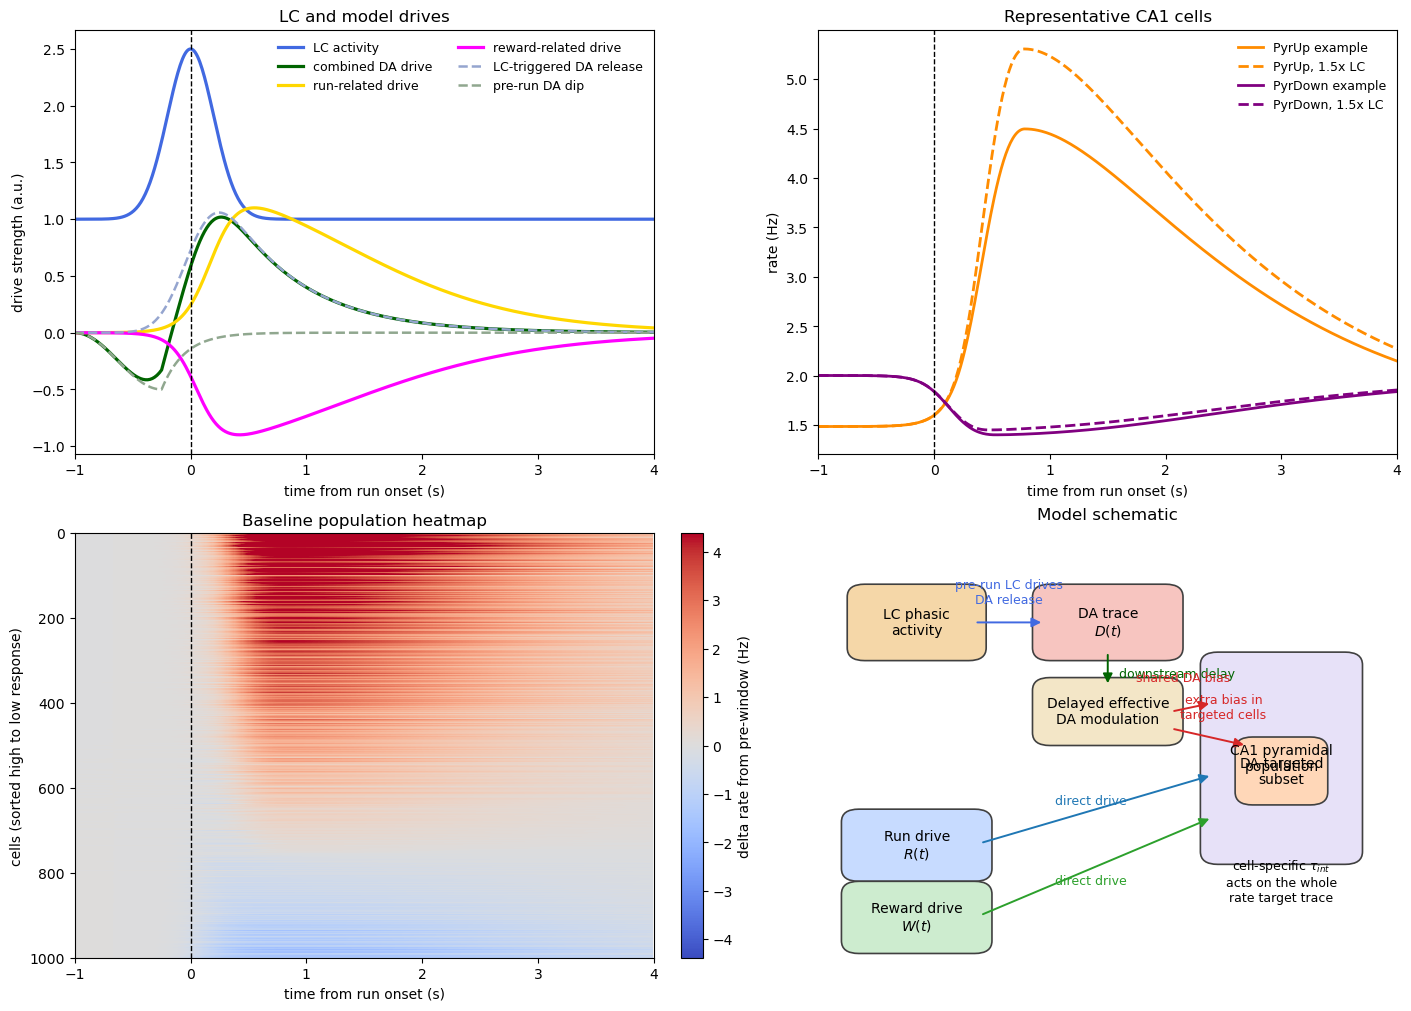

In [33]:
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

t_ref = results['t']
rng_ref = np.random.default_rng(p.seed_start)
ref_pop = make_population(p, rng_ref)

p_ref_lc = deepcopy(p)
p_ref_lc.lc_amp = p.lc_amp * p.lc_activation_fold

ref_base = simulate_population_condition(t_ref, p, ref_pop, da_scale=1.0)
ref_lc = simulate_population_condition(t_ref, p_ref_lc, ref_pop, da_scale=1.0)

pre_mask = window_mask(t_ref, p.pre_window)
late_mask = (t_ref >= 1.0) & (t_ref <= 4.0)
pre_means = np.mean(ref_base['rates'][:, pre_mask], axis=1)
late_deltas = np.mean(ref_lc['rates'][:, late_mask] - ref_base['rates'][:, late_mask], axis=1)
peak_rates = np.max(ref_base['rates'], axis=1)


def representative_index(mask, target_pre, low=None, high=None, favour_delta=False, target_peak=None):
    idx = np.flatnonzero(mask)
    if len(idx) == 0:
        return int(np.nanargmax(ref_base['resp']))

    if low is not None and high is not None:
        in_range = idx[(pre_means[idx] >= low) & (pre_means[idx] <= high)]
        if len(in_range) > 0:
            idx = in_range

    score = np.abs(pre_means[idx] - target_pre)
    if target_peak is not None:
        score = score + 0.20 * np.abs(peak_rates[idx] - target_peak)
    if favour_delta:
        score = score - 0.20 * late_deltas[idx]
    return int(idx[np.argmin(score)])


up_idx = representative_index(ref_base['classes']['is_up'], target_pre=1.50, low=1.0, high=2.0, favour_delta=True, target_peak=4.40)
down_idx = representative_index(ref_base['classes']['is_down'], target_pre=2.00, low=1.8, high=2.5, favour_delta=False, target_peak=3.20)

heatmap = baseline_subtracted_traces(ref_base['rates'], t_ref, p.pre_window)
sort_order = np.argsort(ref_base['resp'])[::-1]
t_mask = (t_ref >= -1.0) & (t_ref <= 4.0)
heatmap = heatmap[sort_order][:, t_mask]
heat_lim = np.nanpercentile(np.abs(heatmap), 97)
if not np.isfinite(heat_lim) or heat_lim <= 0:
    heat_lim = 1.0


def draw_box(ax, xy, width, height, text, facecolor):
    patch = FancyBboxPatch(
        xy,
        width,
        height,
        boxstyle='round,pad=0.02,rounding_size=0.03',
        linewidth=1.2,
        edgecolor='0.25',
        facecolor=facecolor,
    )
    ax.add_patch(patch)
    ax.text(xy[0] + width / 2, xy[1] + height / 2, text, ha='center', va='center', fontsize=10)
    return patch


def draw_arrow(ax, start, end, text=None, text_xy=None, color='0.25'):
    arrow = FancyArrowPatch(start, end, arrowstyle='-|>', mutation_scale=14, linewidth=1.4, color=color)
    ax.add_patch(arrow)
    if text is not None and text_xy is not None:
        ax.text(text_xy[0], text_xy[1], text, fontsize=9, ha='center', va='center', color=color)


fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

ax = axes[0, 0]
ax.plot(t_ref, ref_base['drives']['L'], color='royalblue', linewidth=2.3, label='LC activity')
ax.plot(t_ref, ref_base['drives']['D'], color='darkgreen', linewidth=2.3, label='combined DA drive')
ax.plot(t_ref, ref_base['drives']['R'], color='gold', linewidth=2.3, label='run-related drive')
ax.plot(t_ref, ref_base['drives']['W'], color='magenta', linewidth=2.3, label='reward-related drive')
ax.plot(t_ref, ref_base['drives']['D_release'], color='#95a5cf', linewidth=1.8, linestyle='--', label='LC-triggered DA release')
ax.plot(t_ref, ref_base['drives']['D_dip'], color='#90a78f', linewidth=1.8, linestyle='--', label='pre-run DA dip')
ax.axvline(0, linestyle='--', color='k', linewidth=1)
ax.set_xlim([-1.0, 4.0])
ax.set_xlabel('time from run onset (s)')
ax.set_ylabel('drive strength (a.u.)')
ax.set_title('LC and model drives')
ax.legend(frameon=False, ncol=2, fontsize=9)

ax = axes[0, 1]
ax.plot(t_ref, ref_base['rates'][up_idx], color=class_colors['is_up'], linewidth=2, label='PyrUp example')
ax.plot(
    t_ref,
    ref_lc['rates'][up_idx],
    color=class_colors['is_up'],
    linewidth=2,
    linestyle='--',
    label=f'PyrUp, {p.lc_activation_fold:.1f}x LC',
)
ax.plot(t_ref, ref_base['rates'][down_idx], color=class_colors['is_down'], linewidth=2, label='PyrDown example')
ax.plot(
    t_ref,
    ref_lc['rates'][down_idx],
    color=class_colors['is_down'],
    linewidth=2,
    linestyle='--',
    label=f'PyrDown, {p.lc_activation_fold:.1f}x LC',
)
ax.axvline(0, linestyle='--', color='k', linewidth=1)
ax.set_xlim([-1.0, 4.0])
ax.set_xlabel('time from run onset (s)')
ax.set_ylabel('rate (Hz)')
ax.set_title('Representative CA1 cells')
ax.legend(frameon=False, fontsize=9)

ax = axes[1, 0]
im = ax.imshow(
    heatmap,
    aspect='auto',
    cmap='coolwarm',
    extent=[t_ref[t_mask][0], t_ref[t_mask][-1], heatmap.shape[0], 0],
    vmin=-heat_lim,
    vmax=heat_lim,
    interpolation='nearest',
)
ax.axvline(0, linestyle='--', color='k', linewidth=1)
ax.set_xlim([-1.0, 4.0])
ax.set_xlabel('time from run onset (s)')
ax.set_ylabel('cells (sorted high to low response)')
ax.set_title('Baseline population heatmap')
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('delta rate from pre-window (Hz)')

ax = axes[1, 1]
ax.axis('off')
ax.set_title('Model schematic', pad=10)

draw_box(ax, (0.07, 0.72), 0.20, 0.14, 'LC phasic\nactivity', '#f5d7a8')
draw_box(ax, (0.39, 0.72), 0.22, 0.14, 'DA trace\n$D(t)$', '#f7c5c0')
draw_box(ax, (0.39, 0.52), 0.22, 0.12, 'Delayed effective\nDA modulation', '#f3e6c7')
draw_box(ax, (0.06, 0.20), 0.22, 0.13, 'Run drive\n$R(t)$', '#c7dbff')
draw_box(ax, (0.06, 0.03), 0.22, 0.13, 'Reward drive\n$W(t)$', '#cdeccf')
draw_box(ax, (0.68, 0.24), 0.24, 0.46, 'CA1 pyramidal\npopulation', '#e7e1f8')
draw_box(ax, (0.74, 0.38), 0.12, 0.12, 'DA-targeted\nsubset', '#ffd7b8')

draw_arrow(ax, (0.27, 0.79), (0.39, 0.79), text='pre-run LC drives\nDA release', text_xy=(0.33, 0.86), color='royalblue')
draw_arrow(ax, (0.50, 0.72), (0.50, 0.64), text='downstream delay', text_xy=(0.62, 0.67), color='darkgreen')
draw_arrow(ax, (0.61, 0.58), (0.68, 0.60), text='shared DA bias', text_xy=(0.63, 0.66), color='tab:red')
draw_arrow(ax, (0.61, 0.54), (0.74, 0.50), text='extra bias in\ntargeted cells', text_xy=(0.70, 0.59), color='tab:red')
draw_arrow(ax, (0.28, 0.27), (0.68, 0.43), text='direct drive', text_xy=(0.47, 0.37), color='tab:blue')
draw_arrow(ax, (0.28, 0.10), (0.68, 0.33), text='direct drive', text_xy=(0.47, 0.18), color='tab:green')
ax.text(0.80, 0.18, 'cell-specific $\\tau_{int}$\nacts on the whole\nrate target trace', ha='center', va='center', fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.show()

## 1. LC Activation

Within each bootstrap replicate, LC activation is applied as a **1.5-fold increase in LC amplitude** on the same synthetic population used for baseline. The panels below compare the deterministic LC and full DA signals, the all-cell and PyrUp mean traces, and paired bootstrap summaries shown as **bars with SEM** plus paired scatter points and connecting lines.

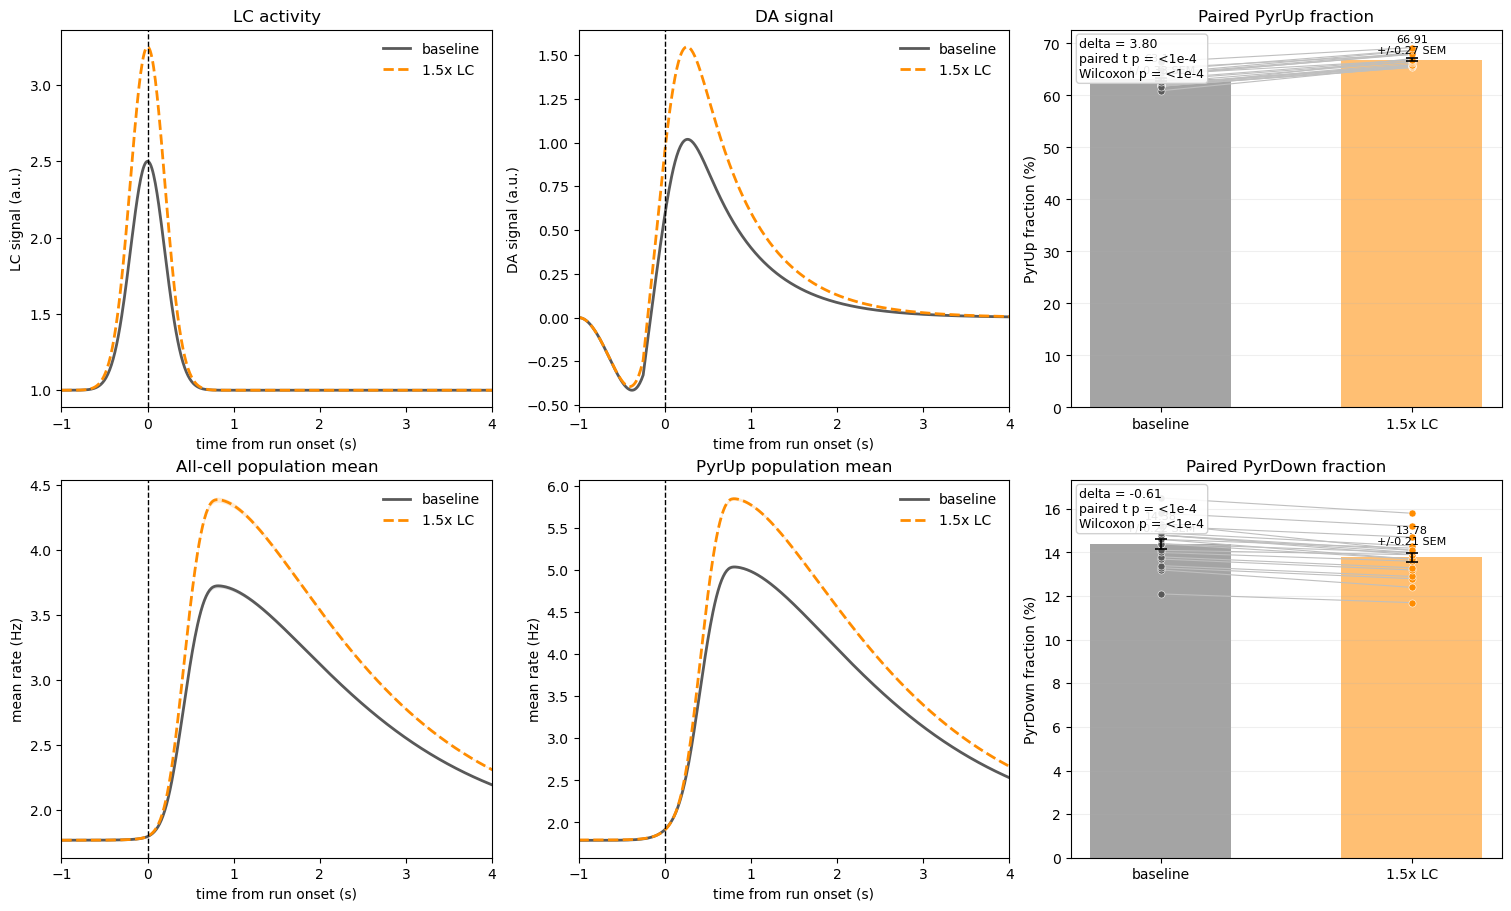

LC activation summary (mean +/- SEM):
  baseline PyrUp (%): 63.11 +/- 0.33 SEM
  1.5x LC PyrUp (%): 66.91 +/- 0.27 SEM
  PyrUp fraction shift (%): delta = 3.80, paired t p = <1e-4, Wilcoxon p = <1e-4
  baseline PyrDown (%): 14.38 +/- 0.22 SEM
  1.5x LC PyrDown (%): 13.78 +/- 0.21 SEM
  PyrDown fraction shift (%): delta = -0.61, paired t p = <1e-4, Wilcoxon p = <1e-4


In [34]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9), constrained_layout=True)

base_drives = results['base_drives']
lc_drives = results['lc_drives']

axes[0, 0].plot(results['t'], base_drives['L'], color=condition_colors['baseline'], linewidth=2, label='baseline')
axes[0, 0].plot(results['t'], lc_drives['L'], color=condition_colors['lc'], linewidth=2, linestyle='--', label=f'{p.lc_activation_fold:.1f}x LC')
axes[0, 0].axvline(0, linestyle='--', color='k', linewidth=1)
axes[0, 0].set_xlim([-1.0, 4.0])
axes[0, 0].set_xlabel('time from run onset (s)')
axes[0, 0].set_ylabel('LC signal (a.u.)')
axes[0, 0].set_title('LC activity')
axes[0, 0].legend(frameon=False)

axes[0, 1].plot(results['t'], base_drives['D'], color=condition_colors['baseline'], linewidth=2, label='baseline')
axes[0, 1].plot(results['t'], lc_drives['D'], color=condition_colors['lc'], linewidth=2, linestyle='--', label=f'{p.lc_activation_fold:.1f}x LC')
axes[0, 1].axvline(0, linestyle='--', color='k', linewidth=1)
axes[0, 1].set_xlim([-1.0, 4.0])
axes[0, 1].set_xlabel('time from run onset (s)')
axes[0, 1].set_ylabel('DA signal (a.u.)')
axes[0, 1].set_title('DA signal')
axes[0, 1].legend(frameon=False)

plot_paired_bar_scatter(
    axes[0, 2],
    results['stats']['base_up_pct'],
    results['stats']['lc_up_pct'],
    labels=['baseline', f'{p.lc_activation_fold:.1f}x LC'],
    colors=[condition_colors['baseline'], condition_colors['lc']],
    ylabel='PyrUp fraction (%)',
    title='Paired PyrUp fraction',
)

plot_mean_sem(axes[1, 0], results['t'], results['base_all_traces'], condition_colors['baseline'], 'baseline')
plot_mean_sem(axes[1, 0], results['t'], results['lc_all_traces'], condition_colors['lc'], f'{p.lc_activation_fold:.1f}x LC', linestyle='--')
axes[1, 0].axvline(0, linestyle='--', color='k', linewidth=1)
axes[1, 0].set_xlim([-1.0, 4.0])
axes[1, 0].set_xlabel('time from run onset (s)')
axes[1, 0].set_ylabel('mean rate (Hz)')
axes[1, 0].set_title('All-cell population mean')
axes[1, 0].legend(frameon=False)

plot_mean_sem(axes[1, 1], results['t'], results['base_up_traces'], condition_colors['baseline'], 'baseline')
plot_mean_sem(axes[1, 1], results['t'], results['lc_up_traces'], condition_colors['lc'], f'{p.lc_activation_fold:.1f}x LC', linestyle='--')
axes[1, 1].axvline(0, linestyle='--', color='k', linewidth=1)
axes[1, 1].set_xlim([-1.0, 4.0])
axes[1, 1].set_xlabel('time from run onset (s)')
axes[1, 1].set_ylabel('mean rate (Hz)')
axes[1, 1].set_title('PyrUp population mean')
axes[1, 1].legend(frameon=False)

plot_paired_bar_scatter(
    axes[1, 2],
    results['stats']['base_down_pct'],
    results['stats']['lc_down_pct'],
    labels=['baseline', f'{p.lc_activation_fold:.1f}x LC'],
    colors=[condition_colors['baseline'], condition_colors['lc']],
    ylabel='PyrDown fraction (%)',
    title='Paired PyrDown fraction',
)

plt.show()

print('LC activation summary (mean +/- SEM):')
print_summary_line('  baseline PyrUp (%)', results['stats']['base_up_pct'])
print_summary_line(f'  {p.lc_activation_fold:.1f}x LC PyrUp (%)', results['stats']['lc_up_pct'])
print_paired_summary('  PyrUp fraction shift (%)', results['stats']['base_up_pct'], results['stats']['lc_up_pct'])
print_summary_line('  baseline PyrDown (%)', results['stats']['base_down_pct'])
print_summary_line(f'  {p.lc_activation_fold:.1f}x LC PyrDown (%)', results['stats']['lc_down_pct'])
print_paired_summary('  PyrDown fraction shift (%)', results['stats']['base_down_pct'], results['stats']['lc_down_pct'])


## 2. DA-Targeted CA1 Cells Are More Likely PyrUp and More Active

This panel uses the baseline condition only. LC now peaks at run onset and the LC-triggered DA release peaks shortly after run onset, while the effective DA modulation of CA1 rises smoothly only after run onset, so the intended targeted-vs-nontargeted separation remains mainly post-run rather than a pre-run bump.

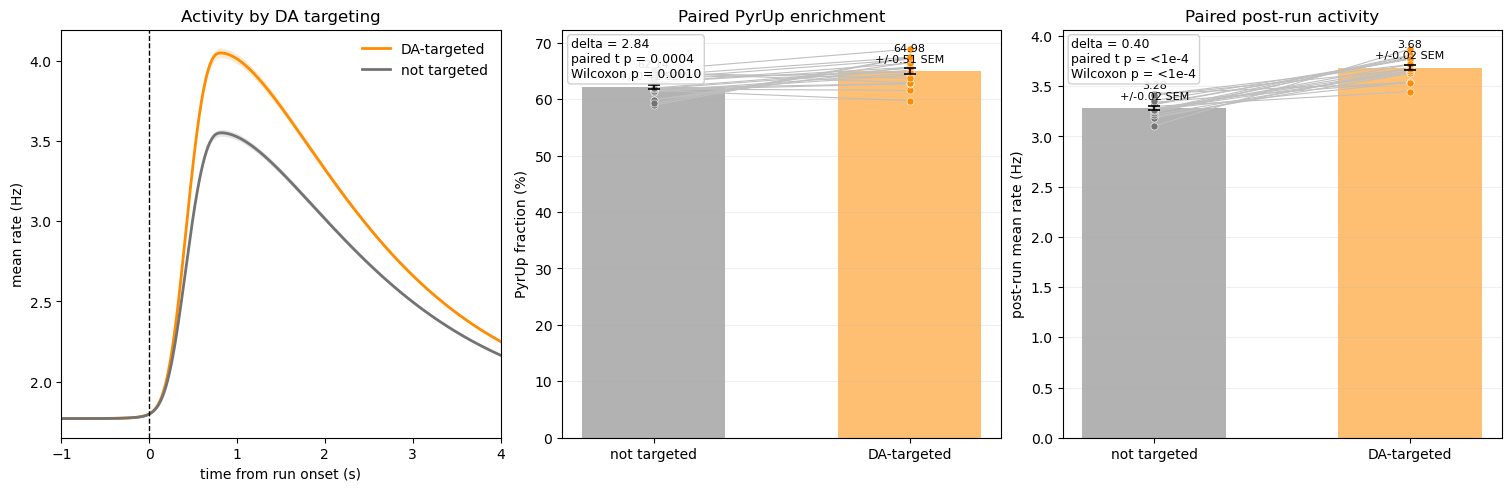

DA-targeting summary (mean +/- SEM):
  P(PyrUp | DA-targeted) (%): 64.98 +/- 0.51 SEM
  P(PyrUp | not targeted) (%): 62.14 +/- 0.41 SEM
  PyrUp enrichment in DA-targeted cells (%): delta = 2.84, paired t p = 0.0004, Wilcoxon p = 0.0010
  post-run rate, DA-targeted (Hz): 3.68 +/- 0.02 SEM
  post-run rate, not targeted (Hz): 3.28 +/- 0.02 SEM
  Post-run rate enrichment in DA-targeted cells (Hz): delta = 0.40, paired t p = <1e-4, Wilcoxon p = <1e-4


In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)

plot_mean_sem(axes[0], results['t'], results['targeted_traces'], condition_colors['da_targeted'], 'DA-targeted')
plot_mean_sem(axes[0], results['t'], results['non_targeted_traces'], condition_colors['not_targeted'], 'not targeted')
axes[0].axvline(0, linestyle='--', color='k', linewidth=1)
axes[0].set_xlim([-1.0, 4.0])
axes[0].set_xlabel('time from run onset (s)')
axes[0].set_ylabel('mean rate (Hz)')
axes[0].set_title('Activity by DA targeting')
axes[0].legend(frameon=False)

plot_paired_bar_scatter(
    axes[1],
    results['stats']['p_up_not_targeted'],
    results['stats']['p_up_da_targeted'],
    labels=['not targeted', 'DA-targeted'],
    colors=[condition_colors['not_targeted'], condition_colors['da_targeted']],
    ylabel='PyrUp fraction (%)',
    title='Paired PyrUp enrichment',
)

plot_paired_bar_scatter(
    axes[2],
    results['stats']['post_rate_not_targeted'],
    results['stats']['post_rate_da_targeted'],
    labels=['not targeted', 'DA-targeted'],
    colors=[condition_colors['not_targeted'], condition_colors['da_targeted']],
    ylabel='post-run mean rate (Hz)',
    title='Paired post-run activity',
)

plt.show()

print('DA-targeting summary (mean +/- SEM):')
print_summary_line('  P(PyrUp | DA-targeted) (%)', results['stats']['p_up_da_targeted'])
print_summary_line('  P(PyrUp | not targeted) (%)', results['stats']['p_up_not_targeted'])
print_paired_summary('  PyrUp enrichment in DA-targeted cells (%)', results['stats']['p_up_not_targeted'], results['stats']['p_up_da_targeted'])
print_summary_line('  post-run rate, DA-targeted (Hz)', results['stats']['post_rate_da_targeted'])
print_summary_line('  post-run rate, not targeted (Hz)', results['stats']['post_rate_not_targeted'])
print_paired_summary('  Post-run rate enrichment in DA-targeted cells (Hz)', results['stats']['post_rate_not_targeted'], results['stats']['post_rate_da_targeted'])

## 3. Partial DA Blockade in CA1

Within each bootstrap replicate, the DA blockade condition is implemented as a **partial reduction of effective DA efficacy** on the same synthetic population used for baseline. In this version the manipulation scales the smooth post-run DA modulatory signal inside CA1, so a stronger partial block primarily increases post-run firing-rate and PyrUp-fraction differences rather than changing the pre-run baseline.

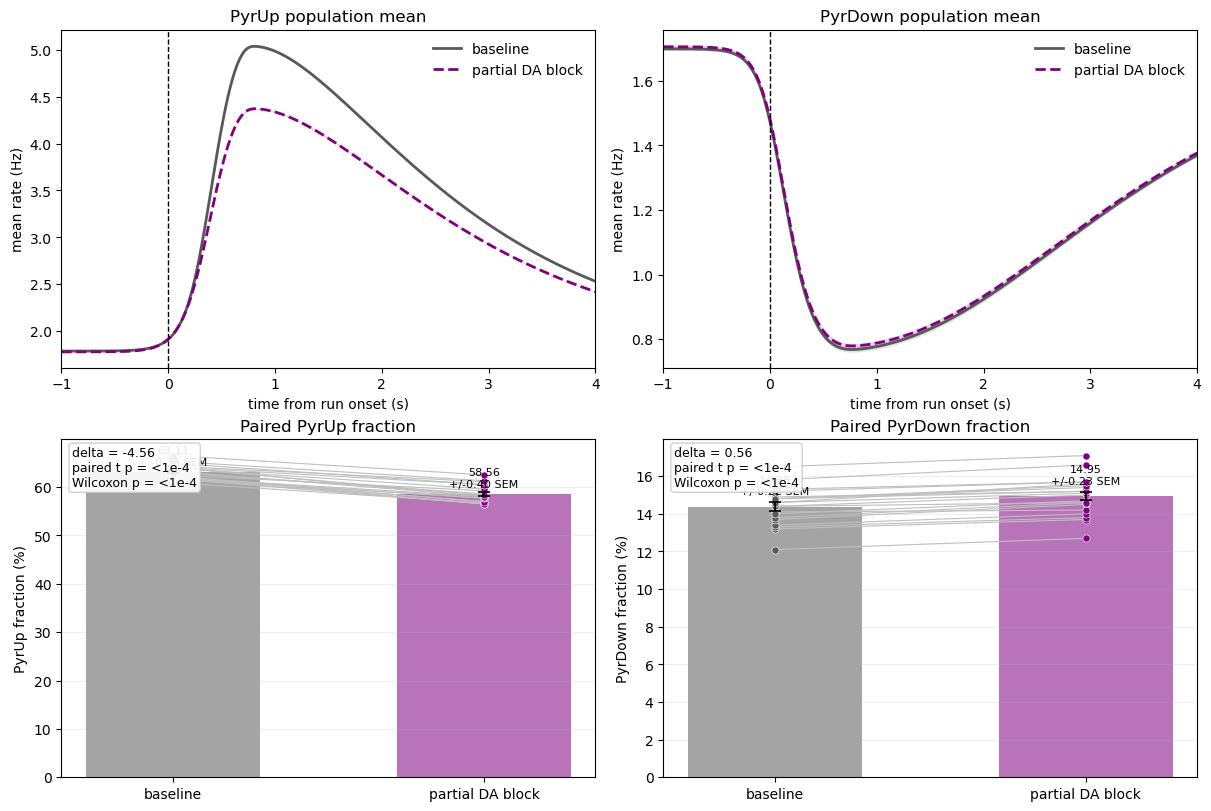

Partial DA blockade summary (mean +/- SEM):
  baseline PyrUp (%): 63.11 +/- 0.33 SEM
  partially blocked PyrUp (%): 58.56 +/- 0.40 SEM
  PyrUp fraction shift (%): delta = -4.56, paired t p = <1e-4, Wilcoxon p = <1e-4
  baseline PyrDown (%): 14.38 +/- 0.22 SEM
  partially blocked PyrDown (%): 14.95 +/- 0.23 SEM
  PyrDown fraction shift (%): delta = 0.56, paired t p = <1e-4, Wilcoxon p = <1e-4


In [36]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

plot_mean_sem(axes[0, 0], results['t'], results['base_up_traces'], condition_colors['baseline'], 'baseline')
plot_mean_sem(axes[0, 0], results['t'], results['block_up_traces'], condition_colors['blocked'], 'partial DA block', linestyle='--')
axes[0, 0].axvline(0, linestyle='--', color='k', linewidth=1)
axes[0, 0].set_xlim([-1.0, 4.0])
axes[0, 0].set_xlabel('time from run onset (s)')
axes[0, 0].set_ylabel('mean rate (Hz)')
axes[0, 0].set_title('PyrUp population mean')
axes[0, 0].legend(frameon=False)

plot_mean_sem(axes[0, 1], results['t'], results['base_down_traces'], condition_colors['baseline'], 'baseline')
plot_mean_sem(axes[0, 1], results['t'], results['block_down_traces'], condition_colors['blocked'], 'partial DA block', linestyle='--')
axes[0, 1].axvline(0, linestyle='--', color='k', linewidth=1)
axes[0, 1].set_xlim([-1.0, 4.0])
axes[0, 1].set_xlabel('time from run onset (s)')
axes[0, 1].set_ylabel('mean rate (Hz)')
axes[0, 1].set_title('PyrDown population mean')
axes[0, 1].legend(frameon=False)

plot_paired_bar_scatter(
    axes[1, 0],
    results['stats']['base_up_pct'],
    results['stats']['block_up_pct'],
    labels=['baseline', 'partial DA block'],
    colors=[condition_colors['baseline'], condition_colors['blocked']],
    ylabel='PyrUp fraction (%)',
    title='Paired PyrUp fraction',
)

plot_paired_bar_scatter(
    axes[1, 1],
    results['stats']['base_down_pct'],
    results['stats']['block_down_pct'],
    labels=['baseline', 'partial DA block'],
    colors=[condition_colors['baseline'], condition_colors['blocked']],
    ylabel='PyrDown fraction (%)',
    title='Paired PyrDown fraction',
)

plt.show()

print('Partial DA blockade summary (mean +/- SEM):')
print_summary_line('  baseline PyrUp (%)', results['stats']['base_up_pct'])
print_summary_line('  partially blocked PyrUp (%)', results['stats']['block_up_pct'])
print_paired_summary('  PyrUp fraction shift (%)', results['stats']['base_up_pct'], results['stats']['block_up_pct'])
print_summary_line('  baseline PyrDown (%)', results['stats']['base_down_pct'])
print_summary_line('  partially blocked PyrDown (%)', results['stats']['block_down_pct'])
print_paired_summary('  PyrDown fraction shift (%)', results['stats']['base_down_pct'], results['stats']['block_down_pct'])


## Interpretation and Caveats

This notebook should still be read as a **phenomenological systems-neuroscience model**, not a biophysical circuit model.

What the bootstrap adds:
- it makes the figure-level conclusions less dependent on one convenient RNG seed
- it keeps each manipulation **paired** to its own baseline population, which is the fairest comparison for this model

What it does **not** add:
- it does not infer uncertainty from recorded experimental cells directly
- it does not model trial-to-trial variability, recurrent CA1 circuitry, or receptor-level DA biology in detail
- it treats DA sensitivity as a weak shared population effect plus an extra targeted increment, which is still a simplified abstraction

So the figures here should be interpreted as support for the **logic of the model assumptions** under repeated synthetic-population resampling, not as proof that the real circuit uses these exact equations.
